In [108]:
# Regression (Supervised learning)

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

In [110]:
data = {
    "Area": [800, 1000, 1200, 1500, 1800, 2000, 2200, 2500, 2800, 3000,
             1100, 1400, 1700, 2100, 2400],
    
    "Bedrooms": [2, 2, 3, 3, 4, 4, 4, 5, 5, 5,
                 2, 3, 4, 4, 5],
    
    "Age": [20, 15, 10, 8, 5, 4, 3, 2, 2, 1,
            18, 12, 6, 4, 2],
    
    "Distance": [10, 8, 7, 6, 5, 4, 4, 3, 2, 2,
                 9, 7, 5, 4, 3],
    
    "Price": [40, 50, 65, 80, 100, 115, 130, 150, 175, 190,
              55, 75, 95, 125, 145]
}

df = pd.DataFrame(data)

print(df)

    Area  Bedrooms  Age  Distance  Price
0    800         2   20        10     40
1   1000         2   15         8     50
2   1200         3   10         7     65
3   1500         3    8         6     80
4   1800         4    5         5    100
5   2000         4    4         4    115
6   2200         4    3         4    130
7   2500         5    2         3    150
8   2800         5    2         2    175
9   3000         5    1         2    190
10  1100         2   18         9     55
11  1400         3   12         7     75
12  1700         4    6         5     95
13  2100         4    4         4    125
14  2400         5    2         3    145


In [111]:
X = df.drop("Price",axis=1)
y=df["Price"]

#X= independent variables
#y= Dependent variables

#X -> Area, Bedrooms,Age, Distance
#y -> Price

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
# 80% training and 20% testing

In [113]:
# Linear Regression

Coefficient: 0.06872599954822677
Intercept: -20.632482493788075
Predicted Prices: [185.54551615  75.58391687  34.34831714]
R2 Score: 0.9957679373986557
MAE: 3.5633611926812825
MSE: 17.374968124408337
RMSE: 4.168329176589625


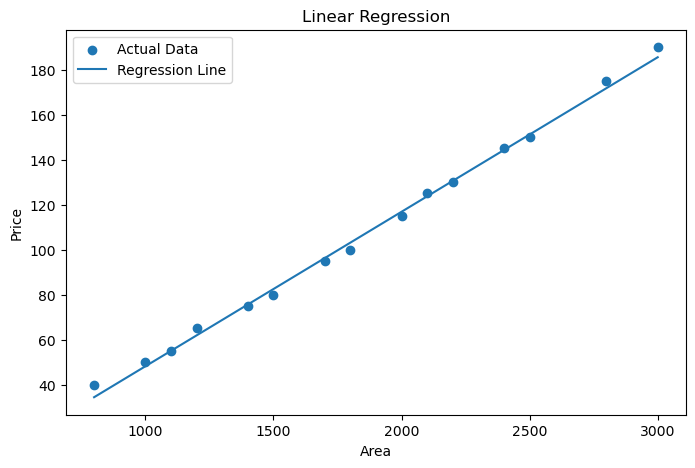

In [114]:
X_single = df[["Area"]]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X_single,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Coefficient:",model.coef_[0])
print("Intercept:",model.intercept_)

print("Predicted Prices:",y_pred)

print("R2 Score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

#creating regression lines
X_line = np.linspace(X["Area"].min(),
                     X["Area"].max(),100).reshape(-1,1)
y_line = model.predict(pd.DataFrame(X_line,columns=["Area"]))

#Graph
plt.figure(figsize=(8,5))
plt.scatter(X["Area"],y,label="Actual Data")
plt.plot(X_line,y_line,label="Regression Line")
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Linear Regression")
plt.legend()
plt.show()


In [115]:
new_house = pd.DataFrame({
              "Area":[1600]
            })
prediction = model.predict(new_house)
print("Predicted Price:", prediction[0])

Predicted Price: 89.32911678337474


In [116]:
#Multiple Linear Regression

Intercept: -3.5676911151136323
Coefficients: [ 0.06509428 -0.0196074   1.03748205 -3.41447983]
Predictions: [185.82561957  76.05389754  35.07335674]
R2 Score: 0.9965243870801053
MAE: 3.3849737428087274
MSE: 14.269321932234567
RMSE: 3.777475603128969
Multiple Linear Regression


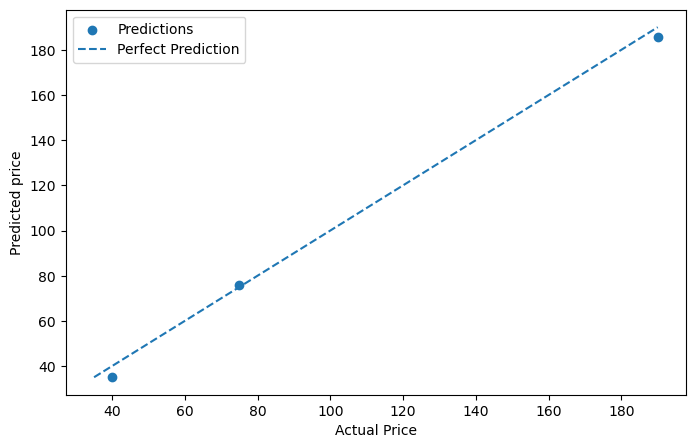

In [117]:
X = df[["Area","Bedrooms","Age","Distance"]]
y = df["Price"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()

model.fit(X_train,y_train)
y_pred = model.predict(X_test)

print("Intercept:",model.intercept_)
print("Coefficients:",model.coef_)
print("Predictions:",y_pred)

print("R2 Score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

#Graph
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred,label="Predictions")
#perfect prediction line
plt.plot([min(y_test.min(),y_pred.min()),max(y_test.max(),y_pred.max())],
         [min(y_test.min(),y_pred.min()),max(y_test.max(),y_pred.max())],
         linestyle="--",
         label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted price")
print("Multiple Linear Regression")
plt.legend()
plt.show()


In [118]:
new_house = pd.DataFrame({
    "Area":[1600],
    "Bedrooms":[3],
    "Age":[5],
    "Distance":[5]
})
prediction = model.predict(new_house)
print("Predicted Price:", prediction[0])

Predicted Price: 88.63933790839242


In [119]:
## Polynomial Regression

R2 Score: 0.9997201374379906
RMSE: 1.071910115751159


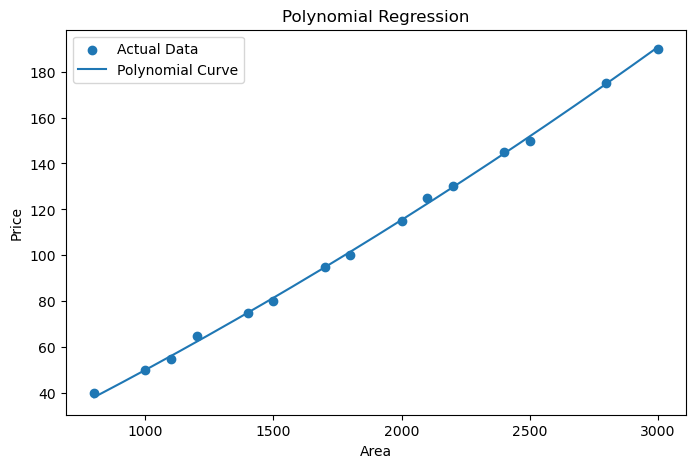

In [120]:
X = df[["Area"]]
y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state=42)

poly_model = Pipeline([("polynomial",PolynomialFeatures(degree=2)),("linear",LinearRegression())])
poly_model.fit(X_train,y_train)
y_pred = poly_model.predict(X_test)

print("R2 Score:",r2_score(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

X_line = np.linspace(X["Area"].min(),X["Area"].max(),200).reshape(-1,1)
X_line_df = pd.DataFrame(X_line,columns=["Area"])
y_line = poly_model.predict(X_line_df)

#Graph
plt.figure(figsize=(8,5))
plt.scatter(X["Area"],y,label="Actual Data")
plt.plot(X_line,y_line,label="Polynomial Curve")
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Polynomial Regression")
plt.legend()
plt.show()

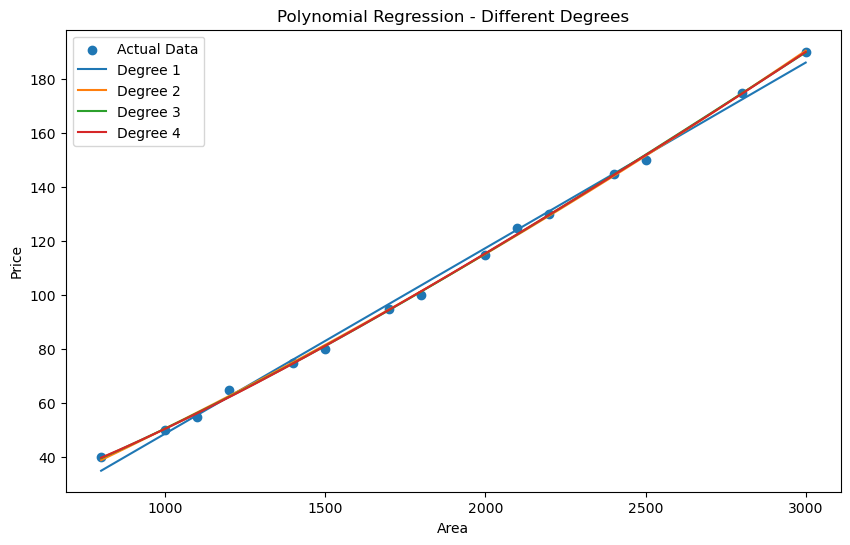

In [121]:
X = df[["Area"]]
y = df["Price"]
plt.figure(figsize=(10,6))
plt.scatter(X["Area"],y,label="Actual Data")
X_line = np.linspace(X["Area"].min(),X["Area"].max(),200).reshape(-1,1)
X_line_df = pd.DataFrame(X_line,columns=["Area"])
for degree in [1,2,3,4]:
    model = Pipeline([("polynomial",PolynomialFeatures(degree=degree)),("linear",LinearRegression())])
    model.fit(X,y)
    y_line = model.predict(X_line_df)
    plt.plot(X_line,y_line,label=f"Degree {degree}")
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Polynomial Regression - Different Degrees")
plt.legend()
plt.show()

In [122]:
new_house = pd.DataFrame({
    "Area":[1600]
})
prediction = poly_model.predict(new_house)
print("Predicted Price:",prediction[0])

Predicted Price: 88.10496952106753


In [123]:
## Ridge Regression

R2 Score: 0.9715682312136557
RMSE: 10.804082853025845


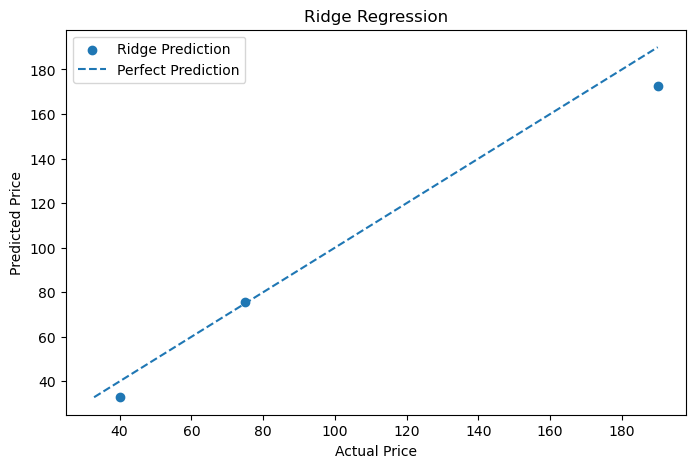

In [124]:
X = df[["Area","Bedrooms","Age","Distance"]]
y=df["Price"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model=Pipeline([("scaler",StandardScaler()),
                ("ridge",Ridge(alpha=1.0))
               ])
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

print("R2 Score:",r2_score(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

#Graph
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred,label="Ridge Prediction")
minimum=min(y_test.min(),y_pred.min())
maximum=max(y_test.max(),y_pred.max())
plt.plot([minimum,maximum],
         [minimum,maximum],
         linestyle="--",
         label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Ridge Regression")
plt.legend()
plt.show()


In [125]:
new_house = pd.DataFrame({
    "Area":[1600],
    "Bedrooms":[3],
    "Age":[5],
    "Distance":[5]
})
prediction = model.predict(new_house)
print("Predicted Price:",prediction[0])

Predicted Price: 92.38560895191786


In [126]:
## Lasso Regression

R2 Score: 0.9967766019894585
RMSE: 3.6378344670896405


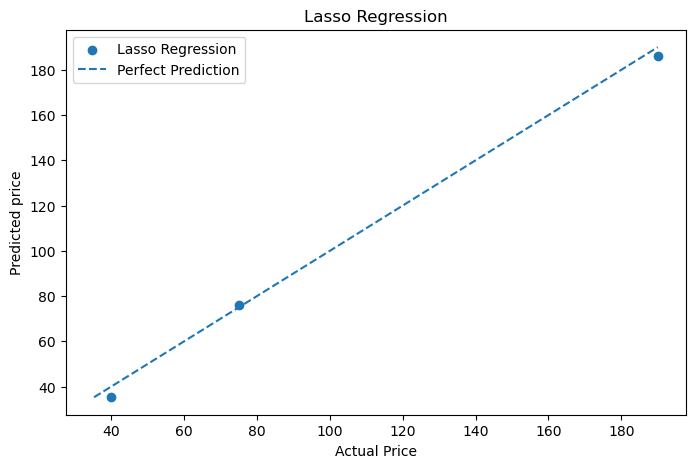

In [127]:
X = df[["Area","Bedrooms","Age","Distance"]]
y=df["Price"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
lasso_model = Pipeline([("scaler",StandardScaler()),("lasso",Lasso(alpha=0.1))])
lasso_model.fit(X_train,y_train)
y_pred = lasso_model.predict(X_test)
print("R2 Score:",r2_score(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

#Graph
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred,label="Lasso Regression")
minimum = min(y_test.min(),y_pred.min())
maximum = max(y_test.max(),y_pred.max())
plt.plot([minimum,maximum],[minimum,maximum],linestyle="--",label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted price")
plt.title("Lasso Regression")
plt.legend()
plt.show()

In [130]:
lasso = lasso_model.named_steps["lasso"]
print("Lasso Coefficients:",lasso.coef_)

Lasso Coefficients: [38.72191636  0.          0.79033576 -0.        ]


In [131]:
## Elastic Net Regression

R2 Score: 0.9796607290870305
MSE: 83.50400669269133
RMSE: 9.138052675088458


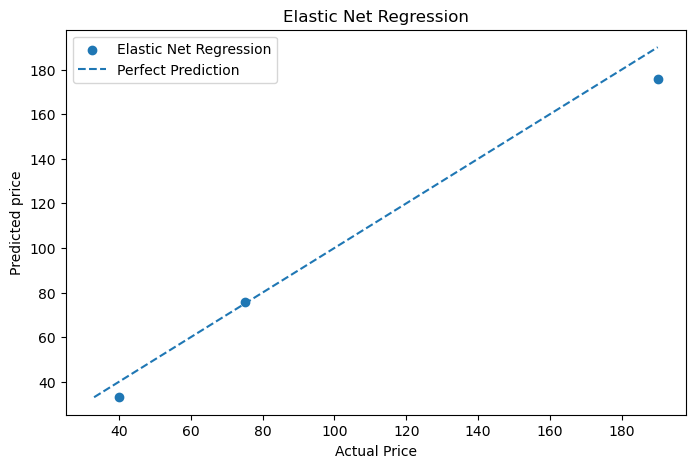

In [132]:
X = df[["Area","Bedrooms","Age","Distance"]]
y=df["Price"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
elastic_model = Pipeline([("scaler",StandardScaler()),("elasticnet",ElasticNet(alpha=0.1,l1_ratio=0.5,max_iter=10000))])
elastic_model.fit(X_train,y_train)
y_pred = elastic_model.predict(X_test)
print("R2 Score:",r2_score(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

#Graph
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred,label="Elastic Net Regression")
minimum = min(y_test.min(),y_pred.min())
maximum = max(y_test.max(),y_pred.max())
plt.plot([minimum,maximum],[minimum,maximum],linestyle="--",label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted price")
plt.title("Elastic Net Regression")
plt.legend()
plt.show()

In [133]:
new_house = pd.DataFrame({
    "Area":[1600],
    "Bedrooms":[3],
    "Age":[5],
    "Distance":[5]
})
prediction = elastic_model.predict(new_house)
print("Predicted Price:",prediction[0])

Predicted Price: 91.54249937518152
